In [30]:
import pandas as pd
import numpy as np
import pyranges as pe
import os
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
tqdm.pandas()

from data import create_saluki_dataloaders
from model import SalukiModel

In [31]:
checkpoint_path = '/s/project/ml4rg_students/2026/project03/project-half-life/outputs/out_setup/19470366_06-16-13-06/model_best_19470366_06-16-13-06.pt'

In [32]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [33]:
model = SalukiModel()
model.load_state_dict(torch.load(checkpoint_path))
model.eval()
model.to(device)

/scratch/tmp/l_neverov/ipykernel_673987/4211116943.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path))


SalukiModel(
  (initial_conv): Conv1d(6, 64, kernel_size=(5,), stride=(1,), bias=False)
  (middle_blocks): ModuleList(
    (0-5): 6 x ModuleDict(
      (ln): LayerNorm((64,), eps=0.007, elementwise_affine=True)
      (conv): Conv1d(64, 64, kernel_size=(5,), stride=(1,))
      (dropout): Dropout(p=0.3, inplace=False)
      (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (gru_ln): LayerNorm((64,), eps=0.007, elementwise_affine=True)
  (gru): GRU(64, 64, batch_first=True)
  (penultimate_bn): BatchNorm1d(64, eps=0.001, momentum=0.09999999999999998, affine=True, track_running_stats=True)
  (penultimate_dense): Linear(in_features=64, out_features=64, bias=True)
  (penultimate_dropout): Dropout(p=0.3, inplace=False)
  (final_bn): BatchNorm1d(64, eps=0.001, momentum=0.09999999999999998, affine=True, track_running_stats=True)
  (output_heads): ModuleList(
    (0-1): 2 x Linear(in_features=64, out_features=1, bias=True)
  )
)

# Eval on held-out

In [38]:
train_data, eval_data, test_data = create_saluki_dataloaders() 

In [39]:
species = 'human'

species_map = {
    'human': 0,
    'mouse': 1,
}
species_i = species_map[species]

In [42]:
all_outputs, all_targets = [], []

with torch.no_grad():
    for x, y_true in tqdm(eval_data[species_i], total=len(eval_data[species_i])):
        x = x.to(device, dtype=torch.float32)
        y_pred = model(x)
    
        all_targets.append(y_true.clone().squeeze())
        all_outputs.append(y_pred.cpu().clone().squeeze())

all_outputs, all_targets = torch.hstack(all_outputs), torch.hstack(all_targets)

100%|██████████| 20/20 [00:02<00:00,  6.97it/s]


In [50]:
from scipy.stats import pearsonr, spearmanr
def pearson(x, y):
    r = pearsonr(x, y)[0]
    return round(r, 4)
def spearman(x, y):
    r = spearmanr(x, y)[0]
    return round(r, 4)

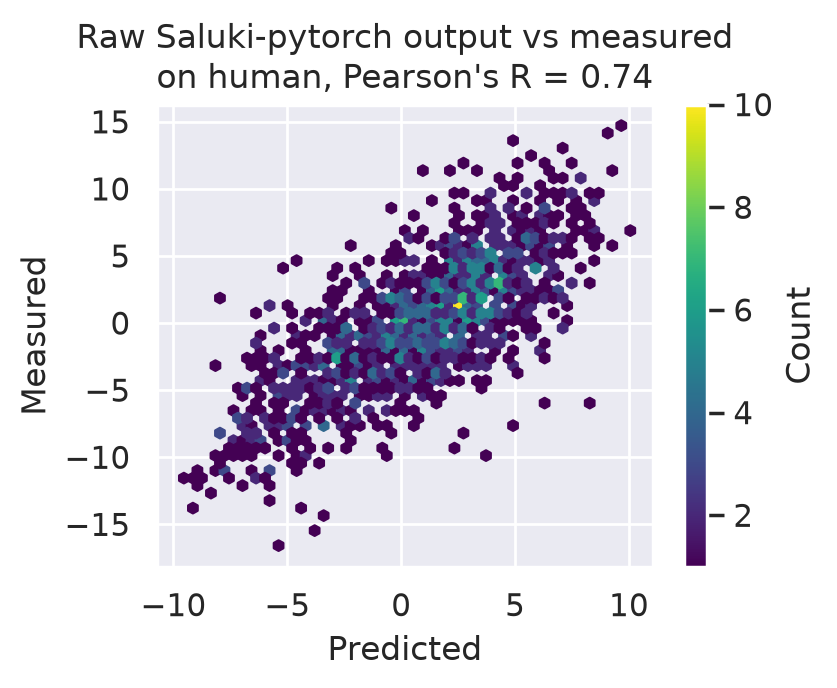

In [80]:
sns.set_theme()

plt.figure(figsize=(4, 3), dpi=200)

hb = plt.hexbin(
    all_outputs,
    all_targets,
    gridsize=50,
    mincnt=1,
    cmap="viridis"
)

plt.colorbar(hb, label="Count")
plt.xlabel("Predicted")
plt.ylabel("Measured")
plt.title(f"Raw Saluki-pytorch output vs measured\non {species}, Pearson's R = {pearson(all_outputs, all_targets):.2f}")
plt.show()

In [56]:
df_toga = pd.read_table('/data/ceph/hdd/project/node_07/ml4rg_students/2026/project03/toga_13_species_updated/saluki_human.hg38.hg38.tsv')

In [60]:
df_toga_val = df_toga[df_toga['fold'] == 1].copy()

In [63]:
df_toga_val['saluki_pytorch_pred'] = all_outputs

In [65]:
pearson(all_outputs, all_targets)

np.float32(0.7432)

In [66]:
pearson(df_toga_val['half_life'], df_toga_val['saluki_pytorch_pred'])

np.float64(0.7432)

In [55]:
df_val_genes = pd.read_csv("/s/project/ml4rg_students/2026/project03/project-half-life/results/val_genes.csv")

In [68]:
df_toga_val = df_toga_val.rename(columns={'gene': 'Gene'})

In [77]:
df_j = df_val_genes.set_index('Gene').join(
    df_toga_val.set_index('Gene')['saluki_pytorch_pred'], how='inner'
).reset_index()

In [78]:
df_j.shape

(1277, 8)

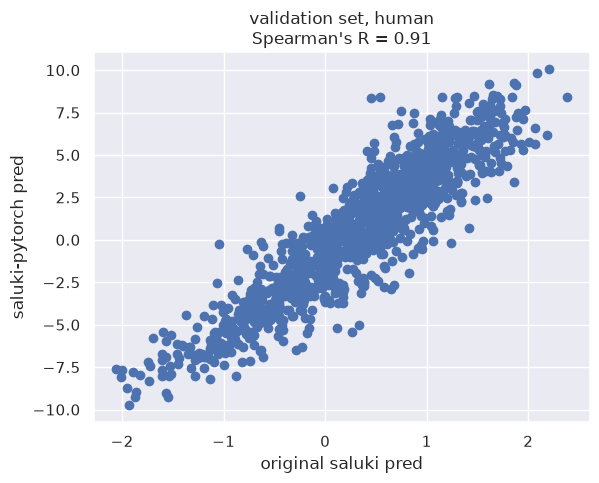

In [79]:
plt.scatter(df_j['orig_saluki_pred'], df_j['saluki_pytorch_pred'])
plt.xlabel('original saluki pred')
plt.ylabel('saluki-pytorch pred')
plt.title(f"validation set, human\nSpearman's R = {spearman(df_j['orig_saluki_pred'], df_j['saluki_pytorch_pred']):.2f}")
plt.show()

# Eval on MPRA

In [151]:
from basenji import dna_io
MAXLEN = 12288

sns.set_theme()

In [251]:
mpra_data_path = '/s/project/ml4rg_students/2026/project03/saluki_paper/Fig6_S7/Siegel_testSet/'

# study = 'Jurkat'
# study = 'Beas2B'
study = ''

suffix = '_' + study if study != '' else ''

In [278]:
df_reporter = pd.read_table(mpra_data_path+"BTV_construct.txt.gz", index_col=0, header=None, compression='gzip')
construct = df_reporter.values

df_mpras = pd.read_table(mpra_data_path+f"fastUTR_mpra{suffix}.txt.gz", header=None, compression='gzip')
seq = df_mpras[[0]][0].values

In [281]:
df_mpras[[0]]

,0
0,AAAAAAAAAAAAAAAAAAAGAAAAGGAGCAGGGAAGGACAGTTCTA...
1,AAAAAAAAAAAAGAAAGGTTGTTATGGACTGGACACCCCTGAAGCC...
2,AAAAAAAAAAAAGAAAGGTTGTTATGGACTGGACACCCCTGAAGCC...
3,AAAAAAAAAAGACAGTCAGTTTACAAAAATATACAATCCTATGGAT...
4,AAAAAAAAAAGACAGTCAGTTTACAAAAATATACAATCCTATGGAT...
...,...
31049,TTTTTTTTTTTTTTGCCGTGTTAGGAAATTATCTATTAATGTACAA...
31050,TTTTTTTTTTTTTTGCCGTGTTAGGAAATTATTTATTAATTTACAA...
31051,TTTTTTTTTTTTTTTAACAATGGTGTGCATGTGCAGGAAATGACAA...
31052,TTTTTTTTTTTTTTTAACAATGGTGTGCATGTGCAGGAAATGACAA...


In [280]:
type(seq)

pandas.arrays.ArrowStringArray

In [253]:
len(seq)

31054

In [254]:
aa_len = int(len(construct[1][0])/3)
coding = np.append(np.zeros(len(construct[0][0])), np.tile([1,0,0], aa_len))

reporter = construct[0]+construct[1]+construct[2]

df_perf = {
    'seq': [],
    'pred': []
}

with torch.no_grad():
    for i in tqdm(seq): # iterate through all sequences
        batch = np.zeros((1,MAXLEN,6))
        myseq = (reporter+i+construct[3])[0]
        batch[0,0:len(myseq),0:4] = dna_io.dna_1hot(myseq)
        batch[0,0:len(coding),4] = coding
        batch = torch.from_numpy(batch).float().to(device)
        pred = model(batch)
        df_perf['seq'].append(i)
        df_perf['pred'].append(pred[0][0].cpu().numpy())

df_perf = pd.DataFrame(df_perf)

100%|██████████| 31054/31054 [02:18<00:00, 224.05it/s]


In [276]:
df_res_publ = pd.read_table(mpra_data_path+f'fastUTR_MPRA_predictions{suffix}.txt.gz', compression='gzip')
# df_targets = pd.read_table(mpra_data_path+'fastUTR_mpra.txt.gz', compression='gzip', header=None)
df_mpras = df_mpras.rename(columns={0: 'seq', 1: 'measured'})

In [256]:
df_res_publ

,seq,Prediction
0,AAAAAAAAAAAAAAAAAAAGAAAAGGAGCAGGGAAGGACAGTTCTA...,0.114381
1,AAAAAAAAAAAAGAAAGGTTGTTATGGACTGGACACCCCTGAAGCC...,-0.367624
2,AAAAAAAAAAAAGAAAGGTTGTTATGGACTGGACACCCCTGAAGCC...,-0.381437
3,AAAAAAAAAAGACAGTCAGTTTACAAAAATATACAATCCTATGGAT...,0.380939
4,AAAAAAAAAAGACAGTCAGTTTACAAAAATATACAATCCTATGGAT...,0.132832
...,...,...
31049,TTTTTTTTTTTTTTGCCGTGTTAGGAAATTATCTATTAATGTACAA...,-0.062474
31050,TTTTTTTTTTTTTTGCCGTGTTAGGAAATTATTTATTAATTTACAA...,-0.439626
31051,TTTTTTTTTTTTTTTAACAATGGTGTGCATGTGCAGGAAATGACAA...,0.092134
31052,TTTTTTTTTTTTTTTAACAATGGTGTGCATGTGCAGGAAATGACAA...,0.113033


In [257]:
df_mpras

,seq,measured,2
0,AAAAAAAAAAAAAAAAAAAGAAAAGGAGCAGGGAAGGACAGTTCTA...,0.594216,NaN
1,AAAAAAAAAAAAGAAAGGTTGTTATGGACTGGACACCCCTGAAGCC...,0.536007,NaN
2,AAAAAAAAAAAAGAAAGGTTGTTATGGACTGGACACCCCTGAAGCC...,0.702001,NaN
3,AAAAAAAAAAGACAGTCAGTTTACAAAAATATACAATCCTATGGAT...,0.546430,NaN
4,AAAAAAAAAAGACAGTCAGTTTACAAAAATATACAATCCTATGGAT...,0.535939,NaN
...,...,...,...
31049,TTTTTTTTTTTTTTGCCGTGTTAGGAAATTATCTATTAATGTACAA...,0.561302,NaN
31050,TTTTTTTTTTTTTTGCCGTGTTAGGAAATTATTTATTAATTTACAA...,0.684154,NaN
31051,TTTTTTTTTTTTTTTAACAATGGTGTGCATGTGCAGGAAATGACAA...,0.542127,NaN
31052,TTTTTTTTTTTTTTTAACAATGGTGTGCATGTGCAGGAAATGACAA...,0.573965,NaN


In [258]:
df_perf['pred'] = df_perf['pred'].astype(float)

In [259]:
df_perf.dtypes

seq         str
pred    float64
dtype: object

In [260]:
df_perf_orig = pd.read_csv('/data/ceph/hdd/project/node_07/ml4rg_students/2026/project03/orig_saluki_Siegel_testSet_pred.csv', sep='\t')

In [261]:
df_j = df_perf.set_index('seq').drop_duplicates().join(
    df_perf_orig.set_index('seq').drop_duplicates(), how='inner', rsuffix='_orig'
).reset_index()

In [262]:
df_j_targ = df_perf.set_index('seq').drop_duplicates().join(
    df_mpras.set_index('seq').drop_duplicates(), how='inner'
).reset_index()

In [263]:
df_j_targ_publ = df_res_publ.set_index('seq').drop_duplicates().join(
    df_mpras.set_index('seq').drop_duplicates(), how='inner'
).reset_index()

In [264]:
df_j_targ_orig = df_perf_orig.set_index('seq').drop_duplicates().join(
    df_mpras.set_index('seq').drop_duplicates(), how='inner'
).reset_index()

In [265]:
df_j.shape, df_j_targ.shape, df_j_targ_orig.shape

((30919, 3), (30952, 4), (31021, 4))

In [266]:
df_j_targ = df_j_targ.drop(columns=2)
df_j_targ = df_j_targ.dropna()

In [267]:
df_j_targ_publ = df_j_targ_publ.drop(columns=2)
df_j_targ_publ = df_j_targ_publ.dropna()

In [268]:
df_j_targ_orig = df_j_targ_orig.drop(columns=2)
df_j_targ_orig = df_j_targ_orig.dropna()

In [270]:
df_j_targ_orig

,seq,pred,measured
0,AAAAAAAAAAAAAAAAAAAGAAAAGGAGCAGGGAAGGACAGTTCTA...,0.744162,0.594216
1,AAAAAAAAAAAAGAAAGGTTGTTATGGACTGGACACCCCTGAAGCC...,0.312153,0.536007
2,AAAAAAAAAAAAGAAAGGTTGTTATGGACTGGACACCCCTGAAGCC...,0.307750,0.702001
3,AAAAAAAAAAGACAGTCAGTTTACAAAAATATACAATCCTATGGAT...,0.972742,0.546430
4,AAAAAAAAAAGACAGTCAGTTTACAAAAATATACAATCCTATGGAT...,0.901588,0.535939
...,...,...,...
31016,TTTTTTTTTTTTTTGCCGTGTTAGGAAATTATCTATTAATGTACAA...,0.787487,0.561302
31017,TTTTTTTTTTTTTTGCCGTGTTAGGAAATTATTTATTAATTTACAA...,0.604848,0.684154
31018,TTTTTTTTTTTTTTTAACAATGGTGTGCATGTGCAGGAAATGACAA...,0.859080,0.542127
31019,TTTTTTTTTTTTTTTAACAATGGTGTGCATGTGCAGGAAATGACAA...,0.865111,0.573965


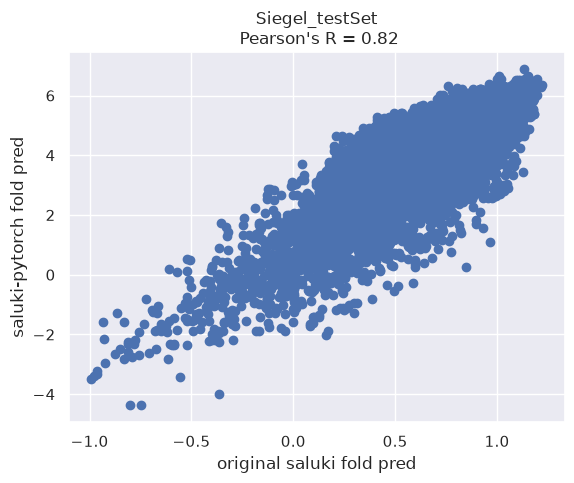

In [274]:
x = df_j['pred_orig'] # orig
y = df_j['pred'] # pytorch

plt.scatter(x, y)
plt.xlabel('original saluki fold pred')
plt.ylabel('saluki-pytorch fold pred')
plt.title(f"Siegel_testSet\n{suffix} Pearson's R = {pearson(x, y):.2f}")
plt.show()

In [229]:
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list(
    "grey_blue_red_yellow",
    [
        "#E5E4E2",  # grey
        "#000080",  # navy
        "#0000ff",  # blue
        "#ff0000",  # red
        "#ff8000",  # orange
        "#ffff00",  # yellow
    ]
)

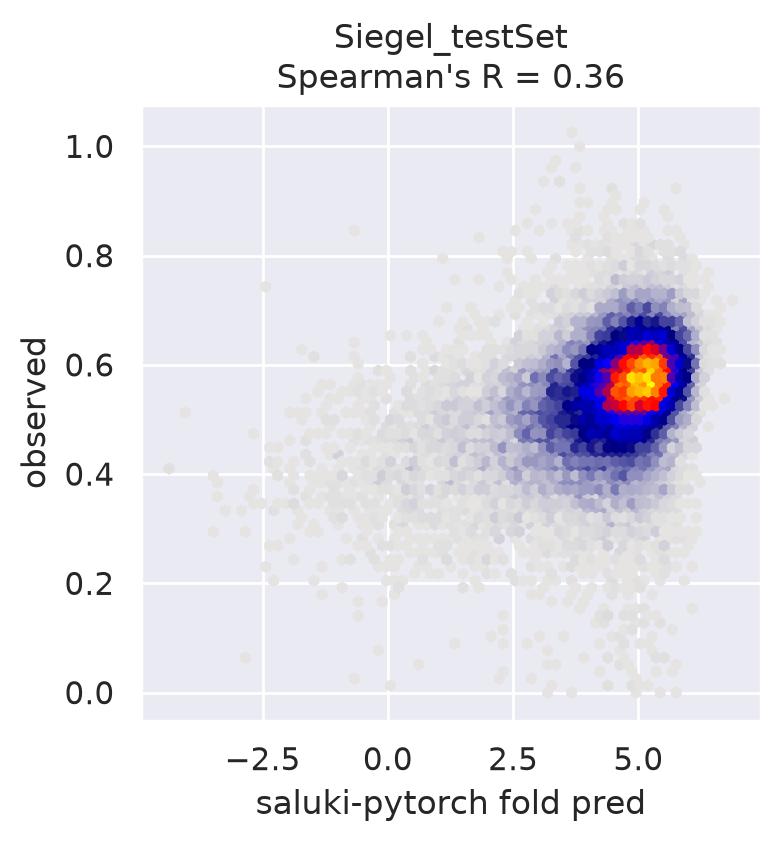

In [250]:
fig = plt.figure(figsize=(4, 4), dpi=200)

x = df_j_targ['pred'] # pytorch
y = df_j_targ['measured']

hb = plt.hexbin(
    x,
    y,
    gridsize=70,
    mincnt=1,
    cmap=cmap
)
plt.xlabel('saluki-pytorch fold pred')
plt.ylabel('observed')
plt.title(f"Siegel_testSet\nSpearman's R = {spearman(x, y):.2f}")
plt.show()

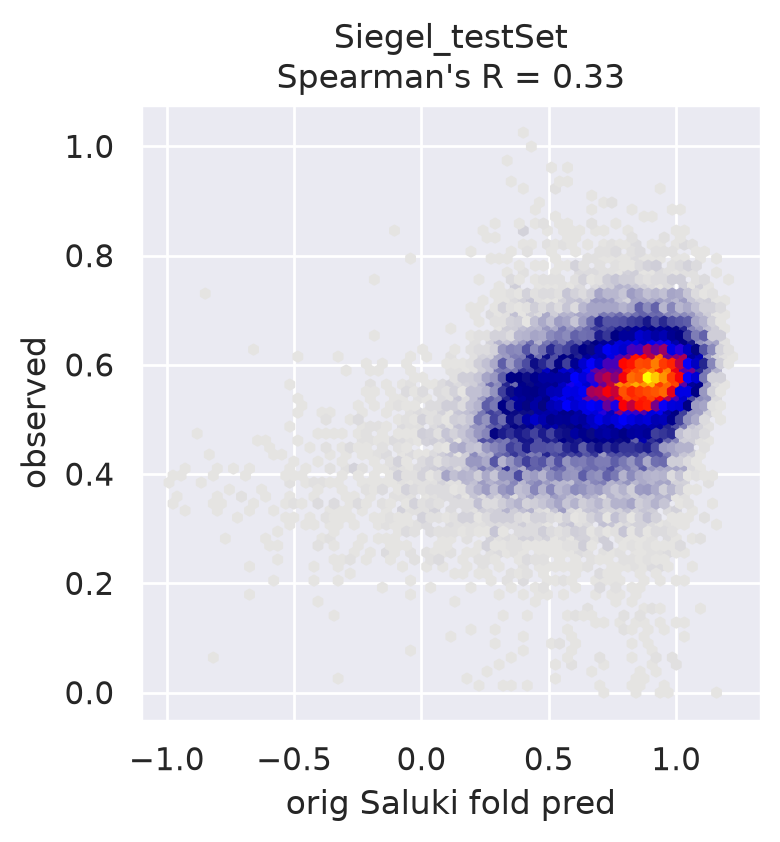

In [249]:
fig = plt.figure(figsize=(4, 4), dpi=200)

x = df_j_targ_orig['pred']
y = df_j_targ_orig['measured']

hb = plt.hexbin(
    x,
    y,
    gridsize=70,
    mincnt=1,
    cmap=cmap
)
plt.xlabel('orig Saluki fold pred')
plt.ylabel('observed')
plt.title(f"Siegel_testSet\nSpearman's R = {spearman(x, y):.2f}")
plt.show()

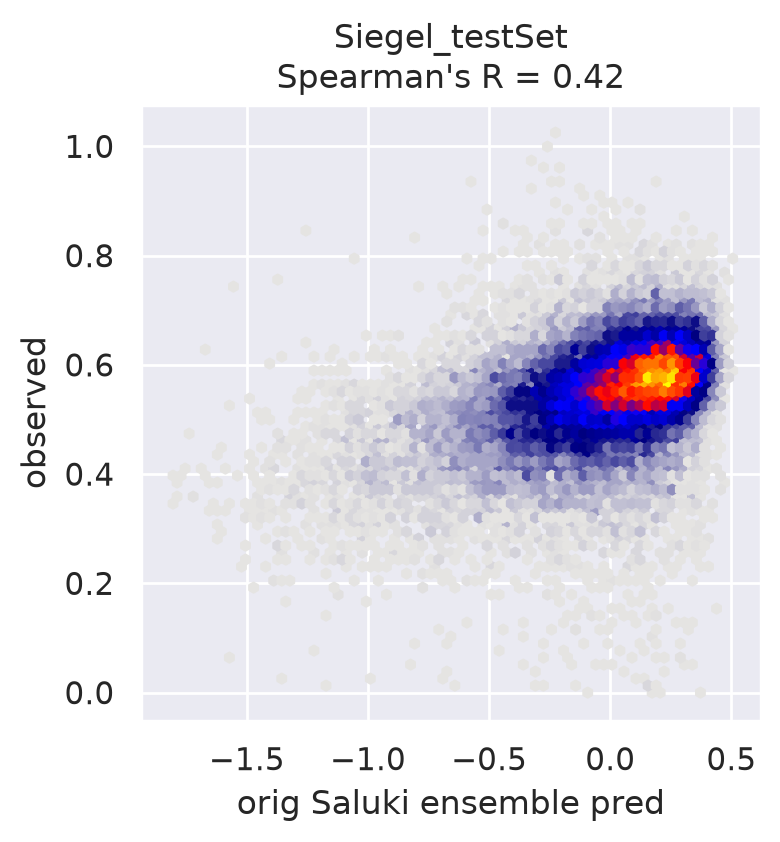

In [246]:
fig = plt.figure(figsize=(4, 4), dpi=200)

x = df_j_targ_publ['Prediction']
y = df_j_targ_publ['measured']

hb = plt.hexbin(
    x,
    y,
    gridsize=70,
    mincnt=1,
    cmap=cmap
)
plt.xlabel('orig Saluki ensemble pred')
plt.ylabel('observed')
plt.title(f"Siegel_testSet\nSpearman's R = {spearman(x, y):.2f}")
plt.show()